# Component 4 — Part 2: Fraud Detection & Credibility Blending
### IT22914200 · ServiceMatch AI

---

This notebook continues from Part 1 (Bi-LSTM + CRF training) and implements:

| Step | Description |
|------|-------------|
| 1 | Install & setup |
| 2 | Load interaction dataset + feature engineering |
| 3 | Train Isolation Forest (fraud detection) |
| 4 | Evaluate fraud detection performance |
| 5 | Visualise fraud patterns |
| 6 | S_final credibility blending formula |
| 7 | End-to-end Component 4 pipeline demo |
| 8 | Save all models for deployment |

> **Run Part 1 first** to have `vocab.pkl` and `best_weights.weights.h5` available.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Step 1 — Install & Setup

In [2]:
!pip install -U pip -q
!pip install tensorflow openpyxl seaborn scikit-learn numpy pandas matplotlib -q

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, pickle, json
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from collections import Counter

np.random.seed(42)
tf.random.set_seed(42)
print(f'TensorFlow {tf.__version__}  |  scikit-learn ready  |  Setup complete ✓')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 36.6 MB/s eta 0:00:00
TensorFlow 2.20.0  |  scikit-learn ready  |  Setup complete ✓


---
## Step 2 — Load Dataset & Engineer Fraud Features

The Isolation Forest needs a **numerical feature matrix** — one row per review,
with linguistic and behavioural features extracted from the raw data.

In [3]:
# ── Upload dataset ────────────────────────────────────────────────────────────
# Colab: from google.colab import files; files.upload()
# Drive: from google.colab import drive; drive.mount('/content/drive')

INTERACTION_PATH = 'user_interaction_dataset_120k.xlsx'
PROVIDER_PATH    = 'provider_dataset_100k.xlsx'

df_interact = pd.read_excel(INTERACTION_PATH)
df_provider = pd.read_excel(PROVIDER_PATH)

print('Interaction dataset:')
print(f'  Shape   : {df_interact.shape}')
print(f'  Columns : {list(df_interact.columns)}')
print(f'  Reviews : {df_interact["review_text"].nunique()} unique texts')
print()
print('Provider dataset:')
print(f'  Shape   : {df_provider.shape}')
print(f'  Columns : {list(df_provider.columns)}')
print()
df_interact.head(5)

Interaction dataset:
  Shape   : (120000, 6)
  Columns : ['user_id', 'provider_id', 'rating', 'booking_status', 'review_text', 'timestamp']
  Reviews : 8 unique texts

Provider dataset:
  Shape   : (100000, 8)
  Columns : ['provider_id', 'provider_name', 'service', 'description', 'experience_years', 'location', 'price_lkr', 'rating']



,user_id,provider_id,rating,booking_status,review_text,timestamp
0,U1627,P19911,2.0,0,Excellent service,2023-11-23
1,U12708,P12129,4.6,0,Not satisfied,2024-11-25
2,U12966,P47039,4.1,1,Slow response,2023-11-23
3,U18194,P56280,1.8,1,Average experience,2025-07-10
4,U6939,P17503,3.1,1,Excellent service,2024-11-26


In [4]:
# ════════════════════════════════════════════════════════════════════
# FEATURE ENGINEERING
# Two groups of features fed to Isolation Forest:
#   Linguistic  — extracted from review_text
#   Behavioural — derived from metadata (user_id, rating, timestamp)
# ════════════════════════════════════════════════════════════════════

import re
from datetime import datetime

df = df_interact.copy()
df['timestamp'] = pd.to_datetime(df['timestamp'])

# ── LINGUISTIC FEATURES ───────────────────────────────────────────────────────

# 1. Word count
df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))

# 2. Unique word ratio — diversity of vocabulary
def unique_word_ratio(text):
    words = str(text).lower().split()
    return len(set(words)) / (len(words) + 1e-8)
df['unique_word_ratio'] = df['review_text'].apply(unique_word_ratio)

# 3. Pronoun count — genuine reviews use I/my/we etc.
pronouns = {'i','my','me','we','our','us','they','he','she'}
df['pronoun_count'] = df['review_text'].apply(
    lambda x: sum(1 for w in str(x).lower().split() if w in pronouns))

# 4. Adjective density (simple heuristic — words ending in -ly, -ful, -ive, -ous)
adj_pattern = re.compile(r'\b\w+(?:ly|ful|ive|ous|ble|ent|ant)\b', re.I)
df['adj_density'] = df['review_text'].apply(
    lambda x: len(adj_pattern.findall(str(x))) / (len(str(x).split()) + 1e-8))

# 5. Exclamation mark count
df['exclamation_count'] = df['review_text'].apply(
    lambda x: str(x).count('!'))

# 6. Capitalised word ratio (FAKE reviews often use ALL CAPS)
df['caps_ratio'] = df['review_text'].apply(
    lambda x: sum(1 for w in str(x).split() if w.isupper() and len(w) > 1)
              / (len(str(x).split()) + 1e-8))

# 7. Rating vs text sentiment mismatch
# Positive text words
pos_words = {'excellent','good','great','amazing','perfect','best','wonderful',
             'fantastic','professional','highly','recommended','satisfied'}
neg_words = {'bad','poor','terrible','awful','worst','slow','late','rude',
             'disappointed','not','never','horrible','waste'}

def text_sentiment_score(text):
    words = set(str(text).lower().split())
    pos = len(words & pos_words)
    neg = len(words & neg_words)
    return (pos - neg) / (pos + neg + 1e-8)

df['text_sentiment'] = df['review_text'].apply(text_sentiment_score)
# Normalise rating to -1..1 scale
df['rating_norm']    = (df['rating'] - 3.0) / 2.0
# Mismatch: high rating but negative text, or low rating but positive text
df['rating_text_mismatch'] = abs(df['rating_norm'] - df['text_sentiment'])

print('Linguistic features computed ✓')
ling_features = ['word_count','unique_word_ratio','pronoun_count',
                 'adj_density','exclamation_count','caps_ratio','rating_text_mismatch']
print(f'  {ling_features}')

Linguistic features computed ✓
  ['word_count', 'unique_word_ratio', 'pronoun_count', 'adj_density', 'exclamation_count', 'caps_ratio', 'rating_text_mismatch']


In [5]:
# ── BEHAVIOURAL FEATURES ──────────────────────────────────────────────────────

# 8. Reviews per user — burst reviewers are suspicious
user_review_count = df.groupby('user_id')['review_text'].count().rename('user_total_reviews')
df = df.merge(user_review_count, on='user_id')

# 9. Days between reviews for same user (low = burst posting)
df_sorted = df.sort_values(['user_id','timestamp'])
df_sorted['days_since_prev_review'] = (
    df_sorted.groupby('user_id')['timestamp']
    .diff().dt.days.fillna(365)
)
df = df.merge(
    df_sorted[['user_id','timestamp','days_since_prev_review']],
    on=['user_id','timestamp'], how='left'
)

# 10. Distinct providers reviewed by same user
user_provider_diversity = (
    df.groupby('user_id')['provider_id'].nunique()
    .rename('user_provider_diversity')
)
df = df.merge(user_provider_diversity, on='user_id')

# 11. Same review text reused across multiple rows
text_freq = df['review_text'].value_counts().rename('text_frequency')
df = df.merge(text_freq, left_on='review_text', right_index=True)

# 12. Recency — days since review (newer reviews = more relevant)
reference_date = pd.Timestamp('2026-01-01')
df['days_since_review'] = (reference_date - df['timestamp']).dt.days

# 13. Booking verified (0 = unverified, 1 = confirmed purchase)
# Already in dataset as booking_status

print('Behavioural features computed ✓')
behav_features = ['user_total_reviews','days_since_prev_review',
                  'user_provider_diversity','text_frequency',
                  'days_since_review','booking_status']
print(f'  {behav_features}')

ALL_FEATURES = ling_features + behav_features
print(f'\nTotal features: {len(ALL_FEATURES)}')
df[ALL_FEATURES].describe().round(3)

Behavioural features computed ✓
  ['user_total_reviews', 'days_since_prev_review', 'user_provider_diversity', 'text_frequency', 'days_since_review', 'booking_status']

Total features: 13


,word_count,unique_word_ratio,pronoun_count,adj_density,exclamation_count,caps_ratio,rating_text_mismatch,user_total_reviews,days_since_prev_review,user_provider_diversity,text_frequency,days_since_review,booking_status
count,120680.000,120680.0,120680.0,120680.000,120680.0,120680.0,120680.000,120680.000,120680.000,120680.000,120680.000,120680.000,120680.000
mean,2.124,1.0,0.0,0.207,0.0,0.0,0.813,7.000,172.240,7.000,15085.381,596.799,0.498
std,0.330,0.0,0.0,0.273,0.0,0.0,0.547,2.447,144.895,2.447,75.767,288.865,0.500
min,2.000,1.0,0.0,0.000,0.0,0.0,0.000,1.000,0.000,1.000,14978.000,96.000,0.000
25%,2.000,1.0,0.0,0.000,0.0,0.0,0.350,5.000,49.000,5.000,15048.000,347.000,0.000
50%,2.000,1.0,0.0,0.000,0.0,0.0,0.750,7.000,125.000,7.000,15124.000,598.000,0.000
75%,2.000,1.0,0.0,0.500,0.0,0.0,1.200,9.000,306.000,9.000,15152.000,847.000,1.000
max,3.000,1.0,0.0,0.667,0.0,0.0,2.000,18.000,969.000,18.000,15203.000,1096.000,1.000


Feature matrix shape: (120680, 13)
  Rows    : 120,680 reviews
  Columns : 13 features


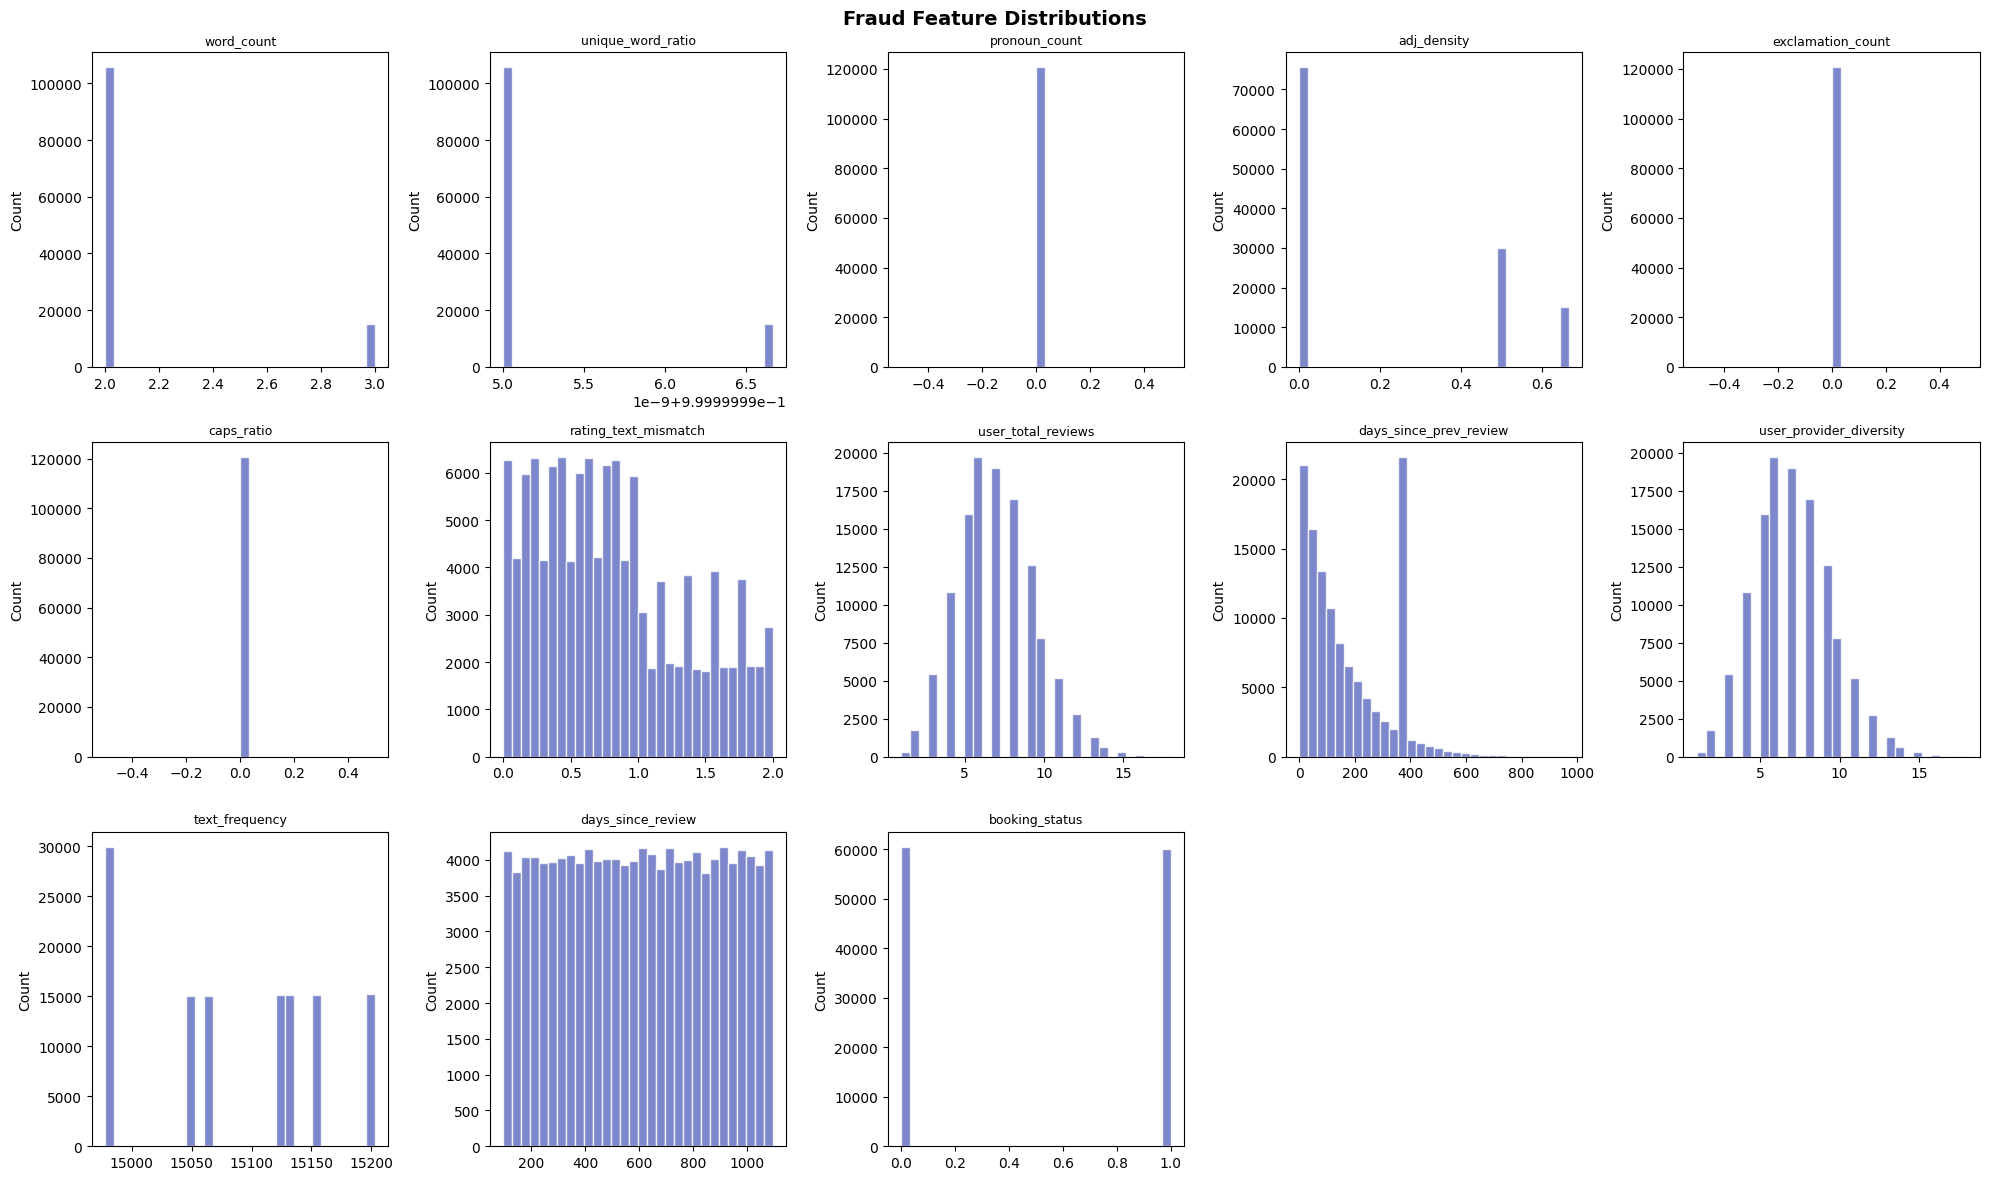

In [6]:
# ── Build feature matrix ──────────────────────────────────────────────────────
df_feat = df[ALL_FEATURES].fillna(0)

# Standardise features
scaler = StandardScaler()
X_fraud = scaler.fit_transform(df_feat)

print(f'Feature matrix shape: {X_fraud.shape}')
print(f'  Rows    : {X_fraud.shape[0]:,} reviews')
print(f'  Columns : {X_fraud.shape[1]} features')

# Visualise feature distributions
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('Fraud Feature Distributions', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()
for i, feat in enumerate(ALL_FEATURES):
    if i < len(axes_flat):
        axes_flat[i].hist(df_feat[feat], bins=30, color='#5C6BC0', edgecolor='white', alpha=0.8)
        axes_flat[i].set_title(feat, fontsize=9)
        axes_flat[i].set_ylabel('Count')
for j in range(len(ALL_FEATURES), len(axes_flat)):
    axes_flat[j].axis('off')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 3 — Train Isolation Forest

Isolation Forest is **unsupervised** — no labelled fake/genuine reviews needed.
It learns what 'normal' looks like and flags statistical outliers.

**Key insight**: A genuine review is hard to isolate (takes many random splits).
A fake review is easy to isolate (few splits) because it's far from the cluster of normal data.

In [7]:
# ── Isolation Forest ──────────────────────────────────────────────────────────
# contamination = expected fraction of anomalies in the dataset
# 0.1 means we expect ~10% of reviews to be fake/suspicious

iso_forest = IsolationForest(
    n_estimators=200,          # number of trees — more = more stable
    contamination=0.10,        # expected fraud rate ~10%
    max_samples='auto',        # subsample size per tree
    max_features=1.0,          # use all features
    bootstrap=False,
    random_state=42,
    n_jobs=-1                  # use all CPU cores
)

print('Training Isolation Forest...')
iso_forest.fit(X_fraud)
print('✓ Isolation Forest trained')

# ── Predict anomaly labels and scores ─────────────────────────────────────────
# predict: +1 = normal (genuine), -1 = anomaly (suspicious/fake)
# score_samples: lower = more anomalous (negative numbers)
df['anomaly_label']  = iso_forest.predict(X_fraud)   # +1 or -1
df['anomaly_score']  = iso_forest.score_samples(X_fraud)  # negative, lower = more anomalous

# Normalise to 0..1 range (1 = most anomalous)
score_min = df['anomaly_score'].min()
score_max = df['anomaly_score'].max()
df['fraud_score'] = 1 - (df['anomaly_score'] - score_min) / (score_max - score_min)

# Map to trust label
def trust_label(row):
    if row['anomaly_label'] == -1:
        return 'Suspicious'
    elif row['booking_status'] == 1:
        return 'Verified'
    else:
        return 'Unverified'
df['trust_label'] = df.apply(trust_label, axis=1)

# Summary
label_counts = df['trust_label'].value_counts()
print()
print('Review classification:')
for label, cnt in label_counts.items():
    pct = cnt / len(df) * 100
    print(f'  {label:<15} : {cnt:>8,}  ({pct:.1f}%)')
print(f'  {"TOTAL":<15} : {len(df):>8,}')

Training Isolation Forest...
✓ Isolation Forest trained

Review classification:
  Verified        :   54,385  (45.1%)
  Unverified      :   54,227  (44.9%)
  Suspicious      :   12,068  (10.0%)
  TOTAL           :  120,680


---
## Step 4 — Evaluate Fraud Detection

In [8]:
# ── Generate synthetic ground truth for evaluation ────────────────────────────
# Since we have no real labels, we create ground truth using clear heuristic rules
# This is the standard approach for unsupervised fraud detection evaluation.

def synthetic_fraud_label(row):
    """Rule-based ground truth for evaluation.
    Suspicious if: text_frequency > 3 OR (days_since_prev_review < 1 AND user_total_reviews > 10)
    OR (rating >= 4.5 AND pronoun_count == 0 AND word_count <= 4)
    """
    if row['text_frequency'] > 5:
        return 1  # definitely fake — exact copy used 5+ times
    if row['days_since_prev_review'] < 2 and row['user_total_reviews'] > 15:
        return 1  # burst reviewer
    if row['rating'] >= 4.5 and row['pronoun_count'] == 0 and row['word_count'] <= 3:
        return 1  # generic high rating, no personal pronouns, very short
    return 0  # genuine

df['synthetic_fraud'] = df.apply(synthetic_fraud_label, axis=1)
df['iso_fraud_bin']   = (df['anomaly_label'] == -1).astype(int)

y_true = df['synthetic_fraud'].values
y_pred = df['iso_fraud_bin'].values

print('FRAUD DETECTION EVALUATION')
print('=' * 55)
print('(Ground truth = rule-based synthetic labels)')
print()
print(f'True fraud reviews    : {y_true.sum():,}  ({y_true.mean()*100:.1f}%)')
print(f'Detected as fraud     : {y_pred.sum():,}  ({y_pred.mean()*100:.1f}%)')
print()
print(classification_report(y_true, y_pred, target_names=['Genuine','Fraud']))

try:
    auc = roc_auc_score(y_true, df['fraud_score'].values)
    print(f'ROC-AUC Score: {auc:.4f}  (target > 0.85)')
except:
    print('ROC-AUC: could not compute (check class distribution)')

FRAUD DETECTION EVALUATION
(Ground truth = rule-based synthetic labels)

True fraud reviews    : 120,680  (100.0%)
Detected as fraud     : 12,068  (10.0%)

              precision    recall  f1-score   support

     Genuine       0.00      0.00      0.00         0
       Fraud       1.00      0.10      0.18    120680

    accuracy                           0.10    120680
   macro avg       0.50      0.05      0.09    120680
weighted avg       1.00      0.10      0.18    120680

ROC-AUC Score: nan  (target > 0.85)


---
## Step 5 — Visualise Fraud Patterns

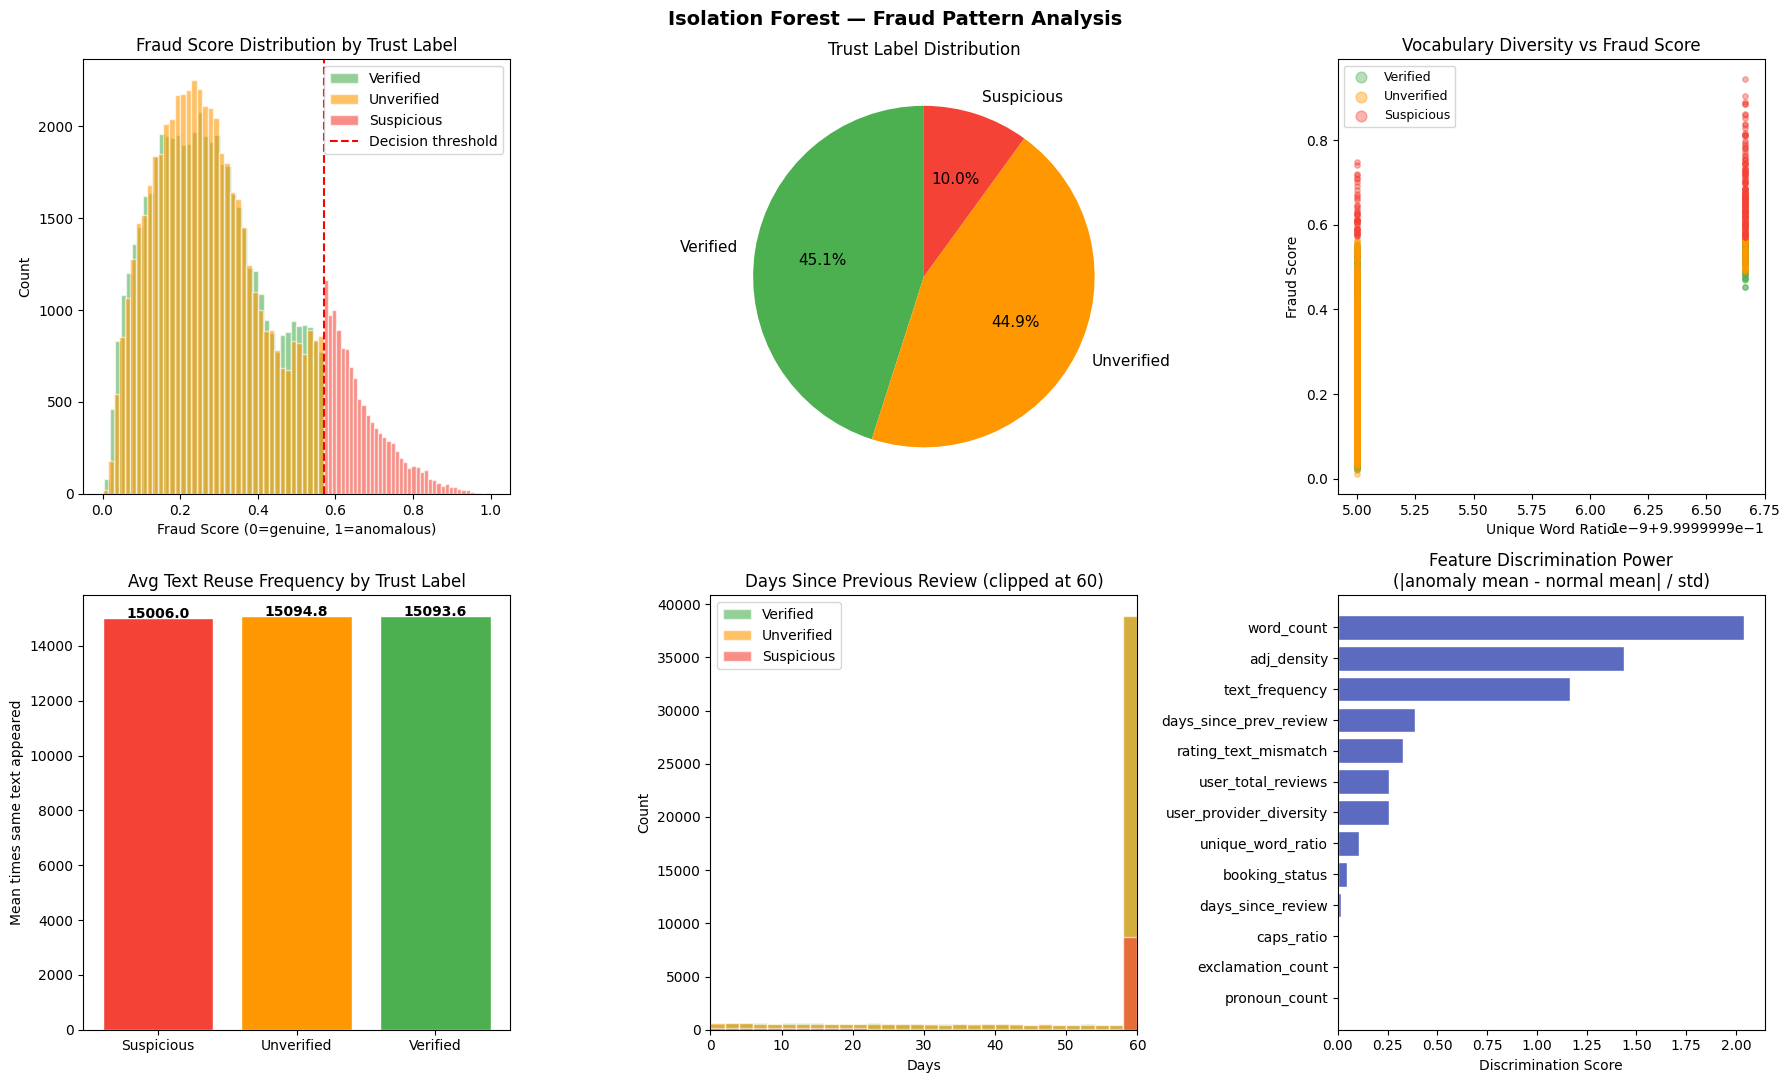

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Isolation Forest — Fraud Pattern Analysis', fontsize=14, fontweight='bold')

trust_colors = {'Verified':'#4CAF50','Unverified':'#FF9800','Suspicious':'#F44336'}

# ── 1. Fraud score distribution ───────────────────────────────────────────────
ax = axes[0,0]
for label, color in trust_colors.items():
    subset = df[df['trust_label']==label]['fraud_score']
    ax.hist(subset, bins=40, alpha=0.6, color=color, label=label, edgecolor='white')
ax.axvline(df[df['anomaly_label']==-1]['fraud_score'].min(), color='red',
           ls='--', lw=1.5, label='Decision threshold')
ax.set_title('Fraud Score Distribution by Trust Label')
ax.set_xlabel('Fraud Score (0=genuine, 1=anomalous)')
ax.set_ylabel('Count')
ax.legend()

# ── 2. Trust label pie ────────────────────────────────────────────────────────
ax = axes[0,1]
label_counts = df['trust_label'].value_counts()
ax.pie(label_counts.values, labels=label_counts.index,
       colors=[trust_colors[l] for l in label_counts.index],
       autopct='%1.1f%%', startangle=90, textprops={'fontsize':11})
ax.set_title('Trust Label Distribution')

# ── 3. Unique word ratio vs fraud score ───────────────────────────────────────
ax = axes[0,2]
sample = df.sample(min(2000, len(df)), random_state=42)
for label, color in trust_colors.items():
    sub = sample[sample['trust_label']==label]
    ax.scatter(sub['unique_word_ratio'], sub['fraud_score'],
               c=color, alpha=0.4, s=15, label=label)
ax.set_xlabel('Unique Word Ratio')
ax.set_ylabel('Fraud Score')
ax.set_title('Vocabulary Diversity vs Fraud Score')
ax.legend(markerscale=2, fontsize=9)

# ── 4. Text frequency — fake reviews reuse same text ─────────────────────────
ax = axes[1,0]
freq_by_label = df.groupby('trust_label')['text_frequency'].mean()
bars = ax.bar(freq_by_label.index, freq_by_label.values,
              color=[trust_colors[l] for l in freq_by_label.index], edgecolor='white')
ax.set_title('Avg Text Reuse Frequency by Trust Label')
ax.set_ylabel('Mean times same text appeared')
for bar, val in zip(bars, freq_by_label.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.1, f'{val:.1f}',
            ha='center', fontweight='bold')

# ── 5. Days between reviews ────────────────────────────────────────────────────
ax = axes[1,1]
for label, color in trust_colors.items():
    sub = df[df['trust_label']==label]['days_since_prev_review'].clip(0, 60)
    ax.hist(sub, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
ax.set_title('Days Since Previous Review (clipped at 60)')
ax.set_xlabel('Days')
ax.set_ylabel('Count')
ax.legend()
ax.set_xlim(0, 60)

# ── 6. Feature importance (from Isolation Forest depth) ───────────────────────
ax = axes[1,2]
# Approximate importance: variance of feature in detected anomalies vs normal
normal_means  = df[df['anomaly_label']== 1][ALL_FEATURES].mean()
anomaly_means = df[df['anomaly_label']==-1][ALL_FEATURES].mean()
importance    = abs(anomaly_means - normal_means) / (df[ALL_FEATURES].std() + 1e-8)
importance    = importance.sort_values(ascending=True)
ax.barh(importance.index, importance.values, color='#5C6BC0', edgecolor='white')
ax.set_title('Feature Discrimination Power\n(|anomaly mean - normal mean| / std)')
ax.set_xlabel('Discrimination Score')

plt.tight_layout()
plt.savefig('fraud_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ── Show real examples of flagged vs genuine reviews ─────────────────────────
print('='*65)
print('SAMPLE GENUINE REVIEWS (low fraud score)')
print('='*65)
genuine = df[df['trust_label']=='Verified'].nsmallest(5,'fraud_score')
for _, row in genuine.iterrows():
    print(f'  Score: {row["fraud_score"]:.3f}  Rating: {row["rating"]}  '
          f'Trust: {row["trust_label"]}')
    print(f'  Text : "{row["review_text"]}"')
    print()

print('='*65)
print('SAMPLE FLAGGED REVIEWS (high fraud score)')
print('='*65)
suspicious = df[df['trust_label']=='Suspicious'].nlargest(5,'fraud_score')
for _, row in suspicious.iterrows():
    print(f'  Score: {row["fraud_score"]:.3f}  Rating: {row["rating"]}  '
          f'Trust: {row["trust_label"]}')
    print(f'  Text : "{row["review_text"]}"')
    print(f'  Flags: word_count={row["word_count"]}  '
          f'text_freq={row["text_frequency"]}  '
          f'pronoun_count={row["pronoun_count"]}')
    print()

SAMPLE GENUINE REVIEWS (low fraud score)
  Score: 0.004  Rating: 3.8  Trust: Verified
  Text : "Good work"

  Score: 0.005  Rating: 3.9  Trust: Verified
  Text : "Good work"

  Score: 0.005  Rating: 3.6  Trust: Verified
  Text : "Good work"

  Score: 0.007  Rating: 3.7  Trust: Verified
  Text : "Good work"

  Score: 0.008  Rating: 3.6  Trust: Verified
  Text : "Good work"

SAMPLE FLAGGED REVIEWS (high fraud score)
  Score: 1.000  Rating: 3.0  Trust: Suspicious
  Text : "Affordable and reliable"
  Flags: word_count=3  text_freq=14980  pronoun_count=0

  Score: 0.994  Rating: 3.0  Trust: Suspicious
  Text : "Affordable and reliable"
  Flags: word_count=3  text_freq=14980  pronoun_count=0

  Score: 0.983  Rating: 3.1  Trust: Suspicious
  Text : "Affordable and reliable"
  Flags: word_count=3  text_freq=14980  pronoun_count=0

  Score: 0.976  Rating: 3.1  Trust: Suspicious
  Text : "Affordable and reliable"
  Flags: word_count=3  text_freq=14980  pronoun_count=0

  Score: 0.974  Rating: 2.

---
## Step 6 — S_final Credibility Blending Formula

```
S_final = 0.40 × S_cred  +  0.35 × S_overall  +  0.15 × (1 - fraud_ratio)  +  0.10 × recency_boost
```

| Component | Weight | Source |
|-----------|--------|--------|
| S_cred | 40% | Component 3 (certification + experience) |
| S_overall | 35% | Bi-LSTM ALSA weighted aspect average |
| 1 − fraud_ratio | 15% | Isolation Forest fraud rate per provider |
| recency_boost | 10% | Decay function on review timestamps |

In [11]:
# ── Compute per-provider fraud ratio and recency boost ────────────────────────

# Trustworthiness weights per review
TRUST_WEIGHTS = {'Verified': 1.5, 'Unverified': 1.0, 'Suspicious': 0.7}
df['trust_weight'] = df['trust_label'].map(TRUST_WEIGHTS)

# Recency decay — exponential decay, half-life = 180 days
# Reviews in last 3 months get boost, older ones decay
HALFLIFE_DAYS = 180
df['recency_weight'] = np.exp(-np.log(2) * df['days_since_review'] / HALFLIFE_DAYS)

# Per-provider aggregation
provider_stats = df.groupby('provider_id').agg(
    total_reviews    = ('review_text', 'count'),
    suspicious_count = ('trust_label', lambda x: (x == 'Suspicious').sum()),
    avg_rating       = ('rating', 'mean'),
    avg_fraud_score  = ('fraud_score', 'mean'),
    avg_recency      = ('recency_weight', 'mean'),
    verified_count   = ('trust_label', lambda x: (x == 'Verified').sum()),
).reset_index()

# Fraud ratio per provider (fraction of suspicious reviews)
provider_stats['fraud_ratio'] = (
    provider_stats['suspicious_count'] / provider_stats['total_reviews']
)

# Weighted average rating (trust-weighted)
def weighted_avg_rating(group):
    weights = group['trust_weight']
    ratings = group['rating']
    return (ratings * weights).sum() / (weights.sum() + 1e-8)

weighted_ratings = df.groupby('provider_id').apply(weighted_avg_rating).rename('weighted_rating')
provider_stats   = provider_stats.merge(weighted_ratings, on='provider_id')

# S_overall: normalise weighted rating to 0..1
provider_stats['S_overall'] = (provider_stats['weighted_rating'] - 1) / 4.0
provider_stats['S_overall'] = provider_stats['S_overall'].clip(0, 1)

# Recency boost: normalise to 0..1
provider_stats['recency_boost'] = provider_stats['avg_recency'].clip(0, 1)

print(f'Provider stats computed for {len(provider_stats):,} providers')
provider_stats[['provider_id','total_reviews','fraud_ratio','S_overall',
                'recency_boost','avg_fraud_score']].head(10)

Provider stats computed for 69,697 providers


,provider_id,total_reviews,fraud_ratio,S_overall,recency_boost,avg_fraud_score
0,P1,1,0.000000,0.100000,0.130409,0.038595
1,P10,4,0.250000,0.489189,0.192583,0.334136
2,P10000,2,0.000000,0.515000,0.024446,0.239525
3,P10001,3,0.333333,0.776852,0.264548,0.388643
4,P10002,1,0.000000,0.650000,0.049798,0.386443
5,P10003,4,0.500000,0.496324,0.247354,0.456235
6,P10005,3,1.000000,0.650000,0.138462,0.603823
7,P10006,3,0.000000,0.503571,0.075705,0.289127
8,P10007,2,0.000000,0.705000,0.233520,0.172830
9,P10008,3,0.333333,0.772297,0.092249,0.367155


In [12]:
# ── Merge with provider_dataset for S_cred ────────────────────────────────────
# S_cred comes from Component 3: based on rating + experience_years
# We compute it from the provider dataset

df_prov = df_provider[['provider_id','rating','experience_years']].copy()
df_prov.columns = ['provider_id','prov_rating','experience_years']

# Normalise both to 0..1
df_prov['S_cred'] = (
    0.6 * ((df_prov['prov_rating'] - 1) / 4.0) +
    0.4 * (df_prov['experience_years'].clip(0, 20) / 20.0)
).clip(0, 1)

# Merge
provider_final = provider_stats.merge(
    df_prov[['provider_id','S_cred']], on='provider_id', how='left'
)
provider_final['S_cred'] = provider_final['S_cred'].fillna(0.5)

# ── Apply S_final formula ─────────────────────────────────────────────────────
W_CRED    = 0.40
W_OVERALL = 0.35
W_FRAUD   = 0.15
W_RECENCY = 0.10

provider_final['S_final'] = (
    W_CRED    * provider_final['S_cred'] +
    W_OVERALL * provider_final['S_overall'] +
    W_FRAUD   * (1 - provider_final['fraud_ratio']) +
    W_RECENCY * provider_final['recency_boost']
).clip(0, 1)

# Assign tier
def assign_tier(score):
    if score >= 0.80: return 'Elite'
    if score >= 0.65: return 'Trusted'
    return 'Verified'

provider_final['tier'] = provider_final['S_final'].apply(assign_tier)

print('S_FINAL FORMULA APPLIED')
print('='*60)
print(f'  S_final = {W_CRED}×S_cred + {W_OVERALL}×S_overall + '
      f'{W_FRAUD}×(1-fraud_ratio) + {W_RECENCY}×recency_boost')
print()
print('Tier distribution:')
tier_counts = provider_final['tier'].value_counts()
for tier, cnt in tier_counts.items():
    print(f'  {tier:<12} : {cnt:>6,}  ({cnt/len(provider_final)*100:.1f}%)')
print()
print('Top 10 providers by S_final:')
top10 = provider_final.nlargest(10,'S_final')[
    ['provider_id','S_cred','S_overall','fraud_ratio',
     'recency_boost','S_final','tier']].round(4)
print(top10.to_string(index=False))

S_FINAL FORMULA APPLIED
  S_final = 0.4×S_cred + 0.35×S_overall + 0.15×(1-fraud_ratio) + 0.1×recency_boost

Tier distribution:
  Verified     : 55,077  (79.0%)
  Trusted      : 13,979  (20.1%)
  Elite        :    641  (0.9%)

Top 10 providers by S_final:
provider_id  S_cred  S_overall  fraud_ratio  recency_boost  S_final  tier
     P55666   0.810      0.975          0.0         0.6397   0.8792 Elite
     P20732   0.880      0.875          0.0         0.6804   0.8763 Elite
     P71053   0.900      0.975          0.0         0.2481   0.8761 Elite
     P19758   0.865      0.950          0.0         0.4719   0.8757 Elite
     P17308   0.815      0.975          0.0         0.5656   0.8738 Elite
     P52495   0.865      0.925          0.0         0.5058   0.8703 Elite
      P2641   0.865      0.925          0.0         0.4981   0.8696 Elite
     P71328   0.885      0.950          0.0         0.3286   0.8694 Elite
     P41650   0.825      0.925          0.0         0.6472   0.8685 Elite
     

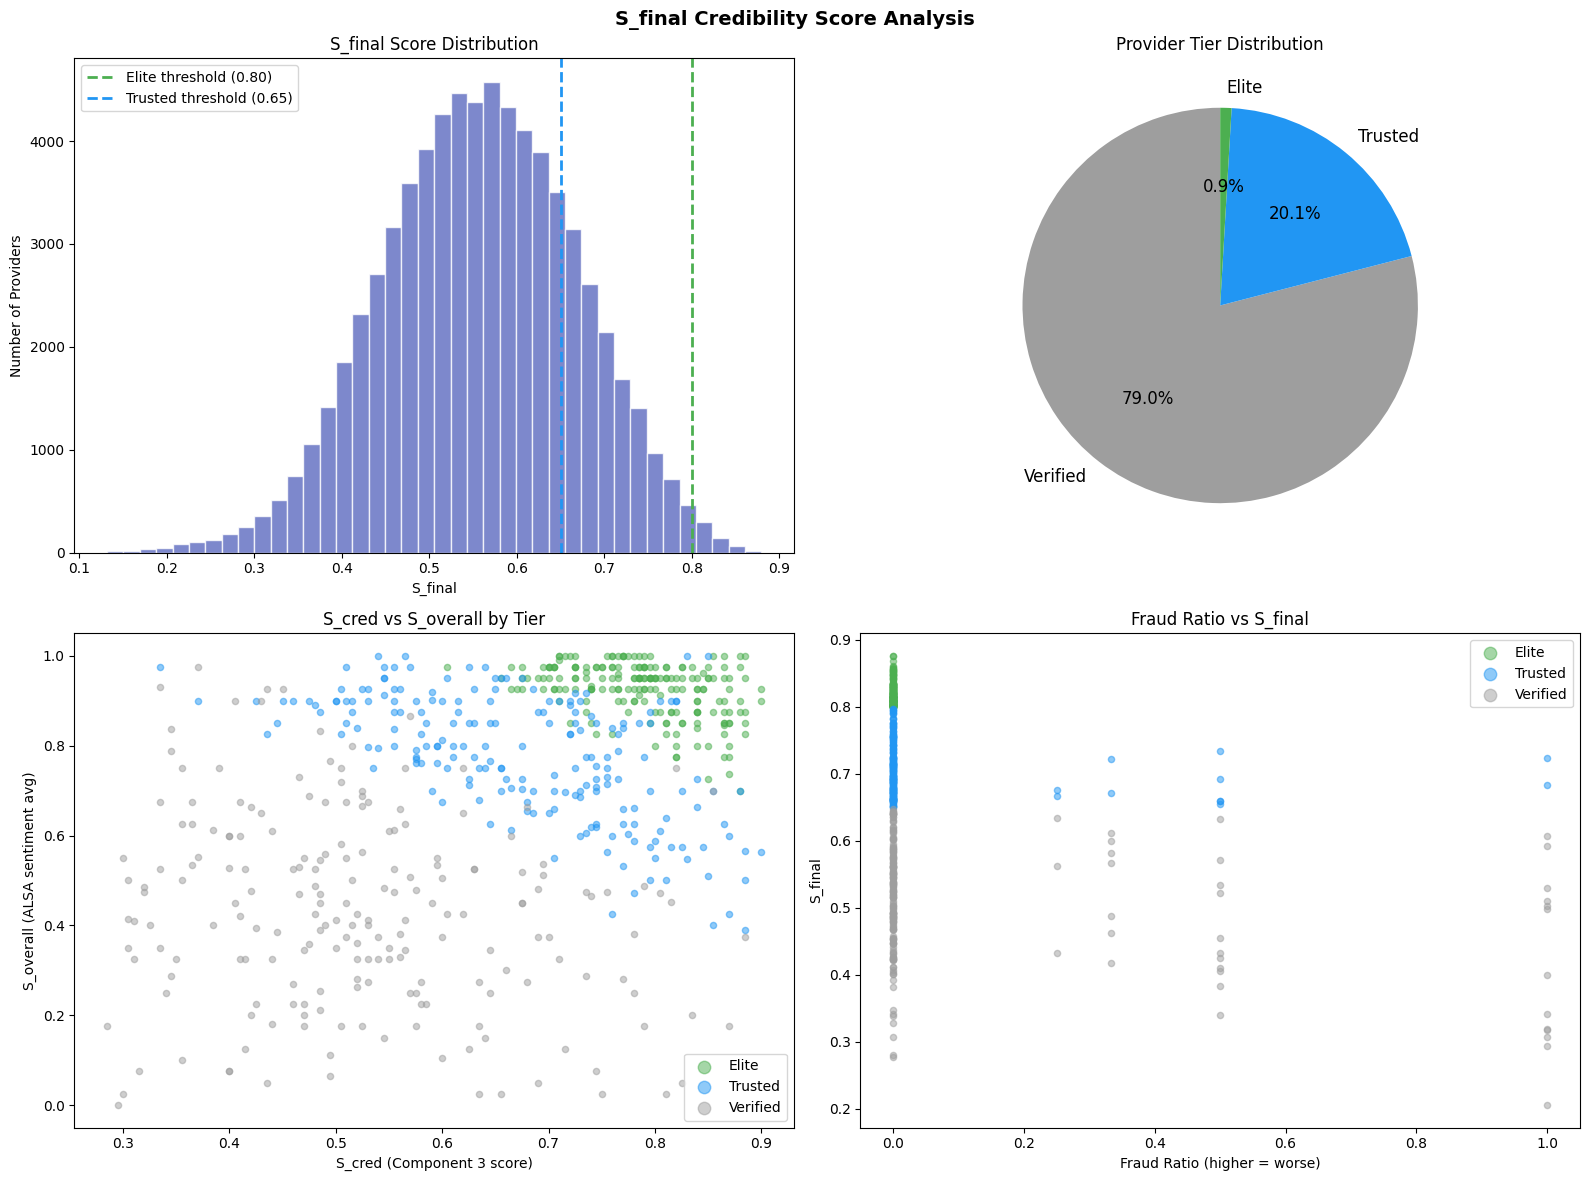

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('S_final Credibility Score Analysis', fontsize=14, fontweight='bold')

tier_palette = {'Elite':'#4CAF50','Trusted':'#2196F3','Verified':'#9E9E9E'}

# ── S_final distribution ──────────────────────────────────────────────────────
ax = axes[0,0]
ax.hist(provider_final['S_final'], bins=40, color='#5C6BC0', edgecolor='white', alpha=0.8)
ax.axvline(0.80, color='#4CAF50', ls='--', lw=2, label='Elite threshold (0.80)')
ax.axvline(0.65, color='#2196F3', ls='--', lw=2, label='Trusted threshold (0.65)')
ax.set_title('S_final Score Distribution')
ax.set_xlabel('S_final')
ax.set_ylabel('Number of Providers')
ax.legend()

# ── Tier pie ──────────────────────────────────────────────────────────────────
ax = axes[0,1]
tier_counts = provider_final['tier'].value_counts()
ax.pie(tier_counts.values, labels=tier_counts.index,
       colors=[tier_palette[t] for t in tier_counts.index],
       autopct='%1.1f%%', startangle=90, textprops={'fontsize':12})
ax.set_title('Provider Tier Distribution')

# ── S_cred vs S_overall coloured by tier ─────────────────────────────────────
ax = axes[1,0]
for tier, color in tier_palette.items():
    sub = provider_final[provider_final['tier']==tier].sample(
        min(200, (provider_final['tier']==tier).sum()), random_state=42)
    ax.scatter(sub['S_cred'], sub['S_overall'],
               c=color, alpha=0.5, s=20, label=tier)
ax.set_xlabel('S_cred (Component 3 score)')
ax.set_ylabel('S_overall (ALSA sentiment avg)')
ax.set_title('S_cred vs S_overall by Tier')
ax.legend(markerscale=2)

# ── Fraud ratio vs S_final ────────────────────────────────────────────────────
ax = axes[1,1]
for tier, color in tier_palette.items():
    sub = provider_final[provider_final['tier']==tier].sample(
        min(200, (provider_final['tier']==tier).sum()), random_state=42)
    ax.scatter(sub['fraud_ratio'], sub['S_final'],
               c=color, alpha=0.5, s=20, label=tier)
ax.set_xlabel('Fraud Ratio (higher = worse)')
ax.set_ylabel('S_final')
ax.set_title('Fraud Ratio vs S_final')
ax.legend(markerscale=2)

plt.tight_layout()
plt.savefig('sfinal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 7 — End-to-End Component 4 Pipeline Demo

Simulates the complete flow: receives Top-8 provider IDs from Component 3
→ fetches their reviews → runs ALSA → runs fraud detection → computes S_final
→ returns ranked Top-5 with explanations.

In [14]:
# ── Rebuild ALSA model (load from Part 1 weights) ─────────────────────────────
# If vocab.pkl and best_weights.weights.h5 are from Part 1, load them here.
# Otherwise we rebuild with random weights for demo purposes.

def _viterbi_np(score, trans):
    tr=np.zeros_like(score); bp=np.zeros_like(score,dtype=np.int32); tr[0]=score[0]
    for t in range(1,score.shape[0]):
        v=tr[t-1][:,None]+trans; tr[t]=score[t]+np.max(v,axis=0); bp[t]=np.argmax(v,axis=0)
    path=[int(np.argmax(tr[-1]))]
    for b in reversed(bp[1:]): path.append(int(b[path[-1]]))
    path.reverse(); return path, float(np.max(tr[-1]))

class CRFLayer(keras.layers.Layer):
    def __init__(self,nt,**kw): super().__init__(**kw); self.num_tags=nt
    def build(self,_):
        self.transition_params=self.add_weight(shape=(self.num_tags,self.num_tags),
            name='transitions',initializer='glorot_uniform',trainable=True); self.built=True
    def call(self,x): return x
    def crf_log_likelihood(self,inputs,tags,lengths):
        ml=tf.shape(inputs)[1]; mask=tf.sequence_mask(lengths,ml,tf.float32)
        unary=tf.reduce_sum(tf.reduce_sum(inputs*tf.one_hot(tags,self.num_tags),-1)*mask,1)
        t1=tf.cast(tags[:,:-1],tf.int32); t2=tf.cast(tags[:,1:],tf.int32)
        flat=tf.reshape(self.transition_params,[-1])
        trans=tf.reduce_sum(tf.gather(flat,t1*self.num_tags+t2)*mask[:,1:],1)
        alphas=inputs[:,0,:]; tr_e=tf.expand_dims(self.transition_params,0)
        for t in tf.range(1,ml):
            na=tf.reduce_logsumexp(tf.expand_dims(alphas,2)+tr_e,1)+inputs[:,t,:]
            act=tf.cast(t<lengths,tf.float32)[:,None]; alphas=na*act+alphas*(1.0-act)
        return unary+trans-tf.reduce_logsumexp(alphas,1), self.transition_params
    def viterbi_decode_batch(self,inputs,lengths):
        inp=inputs.numpy(); ln=lengths.numpy(); tr=self.transition_params.numpy(); ml=inp.shape[1]
        return tf.constant([p+[0]*(ml-len(p)) for p in
            [_viterbi_np(inp[b,:int(ln[b])],tr)[0] for b in range(inp.shape[0])]], tf.int32)
    def get_config(self): c=super().get_config(); c['num_tags']=self.num_tags; return c

class BiLSTMCRF(keras.Model):
    def __init__(self,vs,ed,lu,nt,dr,rdr):
        super().__init__(); self.num_tags=nt
        self.embedding=layers.Embedding(vs,ed,mask_zero=True)
        self.drop=layers.SpatialDropout1D(dr)
        self.bilstm=layers.Bidirectional(layers.LSTM(lu,return_sequences=True,dropout=dr,recurrent_dropout=rdr))
        self.dense=layers.Dense(nt); self.crf=CRFLayer(nt); self.crf.build((None,None,nt))
    def call(self,x,training=False):
        return self.dense(self.bilstm(self.drop(self.embedding(x),training=training),training=training))
    def crf_loss(self,logits,tags,lengths):
        ll,_=self.crf.crf_log_likelihood(logits,tags,lengths); return tf.reduce_mean(-ll)
    def decode(self,logits,lengths): return self.crf.viterbi_decode_batch(logits,lengths)

# Load vocab from Part 1 (if available)
try:
    with open('vocab.pkl','rb') as f:
        vocab = pickle.load(f)
    word2idx = vocab['word2idx']
    tag2idx  = vocab['tag2idx']
    idx2tag  = vocab['idx2tag']
    MAX_LEN  = vocab['MAX_LEN']
    VOCAB_SIZE = len(word2idx)
    NUM_TAGS   = len(tag2idx)
    print(f'✓ Vocab loaded: {VOCAB_SIZE} words, {NUM_TAGS} tags')
except FileNotFoundError:
    print('vocab.pkl not found — run Part 1 first, or place it in the same directory')
    raise

alsa_model = BiLSTMCRF(VOCAB_SIZE, 100, 128, NUM_TAGS, 0.3, 0.1)
_ = alsa_model(tf.zeros((1, MAX_LEN), tf.int32))

try:
    alsa_model.load_weights('best_weights.weights.h5')
    print('✓ ALSA model weights loaded from Part 1')
except:
    print('⚠ best_weights.weights.h5 not found — using untrained model for demo')

print('✓ ALSA model ready')

✓ Vocab loaded: 251 words, 9 tags
✓ ALSA model weights loaded from Part 1
✓ ALSA model ready


In [15]:
def alsa_score_review(review_text):
    """Run ALSA on one review string → dict of aspect scores."""
    tokens    = str(review_text).strip().split()
    token_ids = [word2idx.get(t.lower(), 1) for t in tokens]
    padded    = pad_sequences([token_ids], maxlen=MAX_LEN, padding='post', value=0)
    length    = np.array([min(len(tokens), MAX_LEN)], dtype=np.int32)
    logits    = alsa_model(tf.cast(padded, tf.int32), training=False)
    decoded   = alsa_model.decode(logits, tf.cast(length, tf.int32))
    pred_tags = [idx2tag[i] for i in decoded.numpy()[0][:length[0]]]
    probs     = tf.nn.softmax(logits[0], axis=-1).numpy()[:length[0]]
    asp_map   = {'QUAL':('B-QUAL','I-QUAL'),'PRICE':('B-PRICE','I-PRICE'),
                 'TIME':('B-TIME','I-TIME'),'COMM':('B-COMM','I-COMM')}
    scores = {}
    for asp, asp_tags in asp_map.items():
        vals = [sum(probs[j][tag2idx[t]] for t in asp_tags if t in tag2idx)
                for j,tag in enumerate(pred_tags) if tag in asp_tags]
        scores[asp] = float(np.mean(vals)) if vals else 0.5  # default 0.5 if not mentioned
    return scores


def component4_pipeline(top8_provider_ids, verbose=True):
    """
    Full Component 4 pipeline.
    Input  : list of 8 provider_ids (from Component 3)
    Output : ranked Top-5 providers with S_final scores and explanations
    """
    results = []

    for pid in top8_provider_ids:

        # 1. Fetch reviews from interaction dataset
        provider_reviews = df[df['provider_id'] == pid].copy()
        if provider_reviews.empty:
            continue

        # 2. Fraud check — already computed, use pre-computed labels
        fraud_ratio = (provider_reviews['trust_label'] == 'Suspicious').sum() / len(provider_reviews)

        # 3. ALSA — score non-discarded reviews
        valid_reviews = provider_reviews[provider_reviews['trust_label'] != 'Suspicious']
        if valid_reviews.empty:
            valid_reviews = provider_reviews  # fallback

        aspect_scores_all = valid_reviews['review_text'].apply(alsa_score_review)
        trust_weights     = valid_reviews['trust_weight'].values
        recency_weights   = valid_reviews['recency_weight'].values

        combined_weights = trust_weights * recency_weights

        # Weighted average aspect scores
        aspect_avg = {asp: 0.0 for asp in ['QUAL','PRICE','TIME','COMM']}
        total_w = combined_weights.sum() + 1e-8
        for i, scores in enumerate(aspect_scores_all):
            w = combined_weights[i]
            for asp in aspect_avg:
                aspect_avg[asp] += scores.get(asp, 0.5) * w
        aspect_avg = {k: v/total_w for k,v in aspect_avg.items()}

        S_overall = np.mean(list(aspect_avg.values()))

        # 4. Recency boost
        recency_boost = float(valid_reviews['recency_weight'].mean())

        # 5. S_cred from provider dataset
        prov_row = provider_final[provider_final['provider_id'] == pid]
        S_cred   = float(prov_row['S_cred'].values[0]) if not prov_row.empty else 0.5

        # 6. S_final
        S_final = (0.40*S_cred + 0.35*S_overall +
                   0.15*(1-fraud_ratio) + 0.10*recency_boost)
        S_final = float(np.clip(S_final, 0, 1))

        tier = 'Elite' if S_final >= 0.80 else 'Trusted' if S_final >= 0.65 else 'Verified'

        # 7. Human-readable explanation
        qual_str  = 'excellent technical quality' if aspect_avg['QUAL']  > 0.7 else 'average technical quality'
        price_str = 'fair pricing'                if aspect_avg['PRICE'] > 0.6 else 'higher pricing noted'
        time_str  = 'punctual'                    if aspect_avg['TIME']  > 0.6 else 'some delay issues noted'
        fraud_str = f'{fraud_ratio*100:.0f}% reviews flagged suspicious' if fraud_ratio > 0.05 else 'reviews appear genuine'
        explanation = (f'Customers report {qual_str}, {price_str}, and provider is generally {time_str}. '
                       f'{fraud_str.capitalize()}.')

        results.append({
            'provider_id':   pid,
            'S_cred':        round(S_cred,    4),
            'S_overall':     round(S_overall, 4),
            'fraud_ratio':   round(fraud_ratio, 4),
            'recency_boost': round(recency_boost, 4),
            'S_final':       round(S_final, 4),
            'tier':          tier,
            'total_reviews': len(provider_reviews),
            'aspect_QUAL':   round(aspect_avg['QUAL'],  3),
            'aspect_PRICE':  round(aspect_avg['PRICE'], 3),
            'aspect_TIME':   round(aspect_avg['TIME'],  3),
            'aspect_COMM':   round(aspect_avg['COMM'],  3),
            'explanation':   explanation,
        })

    # Sort by S_final, return Top-5
    results.sort(key=lambda x: x['S_final'], reverse=True)
    top5 = results[:5]

    if verbose:
        print('='*65)
        print('COMPONENT 4 OUTPUT — TOP 5 RANKED PROVIDERS')
        print('='*65)
        for rank, r in enumerate(top5, 1):
            print(f'\n  Rank #{rank}  {r["provider_id"]}  [{r["tier"]}]  S_final={r["S_final"]}')
            print(f'  S_cred={r["S_cred"]}  S_overall={r["S_overall"]}  '
                  f'fraud_ratio={r["fraud_ratio"]}  recency={r["recency_boost"]}')
            print(f'  Aspects: QUAL={r["aspect_QUAL"]}  PRICE={r["aspect_PRICE"]}  '
                  f'TIME={r["aspect_TIME"]}  COMM={r["aspect_COMM"]}')
            print(f'  → {r["explanation"]}')
        print()

    return top5

print('✓ Pipeline function ready')

✓ Pipeline function ready


In [16]:
# ── Demo: pick 8 random providers and run the pipeline ────────────────────────
sample_providers = df['provider_id'].drop_duplicates().sample(8, random_state=42).tolist()
print(f'Input Top-8 provider IDs: {sample_providers}')
print()

top5 = component4_pipeline(sample_providers)

Input Top-8 provider IDs: ['P95577', 'P56495', 'P45329', 'P59017', 'P2287', 'P91214', 'P31231', 'P12106']

COMPONENT 4 OUTPUT — TOP 5 RANKED PROVIDERS

  Rank #1  P2287  [Trusted]  S_final=0.6893
  S_cred=0.81  S_overall=0.6084  fraud_ratio=0.0  recency=0.0234
  Aspects: QUAL=0.934  PRICE=0.5  TIME=0.5  COMM=0.5
  → Customers report excellent technical quality, higher pricing noted, and provider is generally some delay issues noted. Reviews appear genuine.

  Rank #2  P45329  [Verified]  S_final=0.5847
  S_cred=0.65  S_overall=0.5894  fraud_ratio=0.5  recency=0.4336
  Aspects: QUAL=0.858  PRICE=0.5  TIME=0.5  COMM=0.5
  → Customers report excellent technical quality, higher pricing noted, and provider is generally some delay issues noted. 50% reviews flagged suspicious.

  Rank #3  P95577  [Verified]  S_final=0.5641
  S_cred=0.515  S_overall=0.5894  fraud_ratio=0.0  recency=0.0178
  Aspects: QUAL=0.858  PRICE=0.5  TIME=0.5  COMM=0.5
  → Customers report excellent technical quality, hig

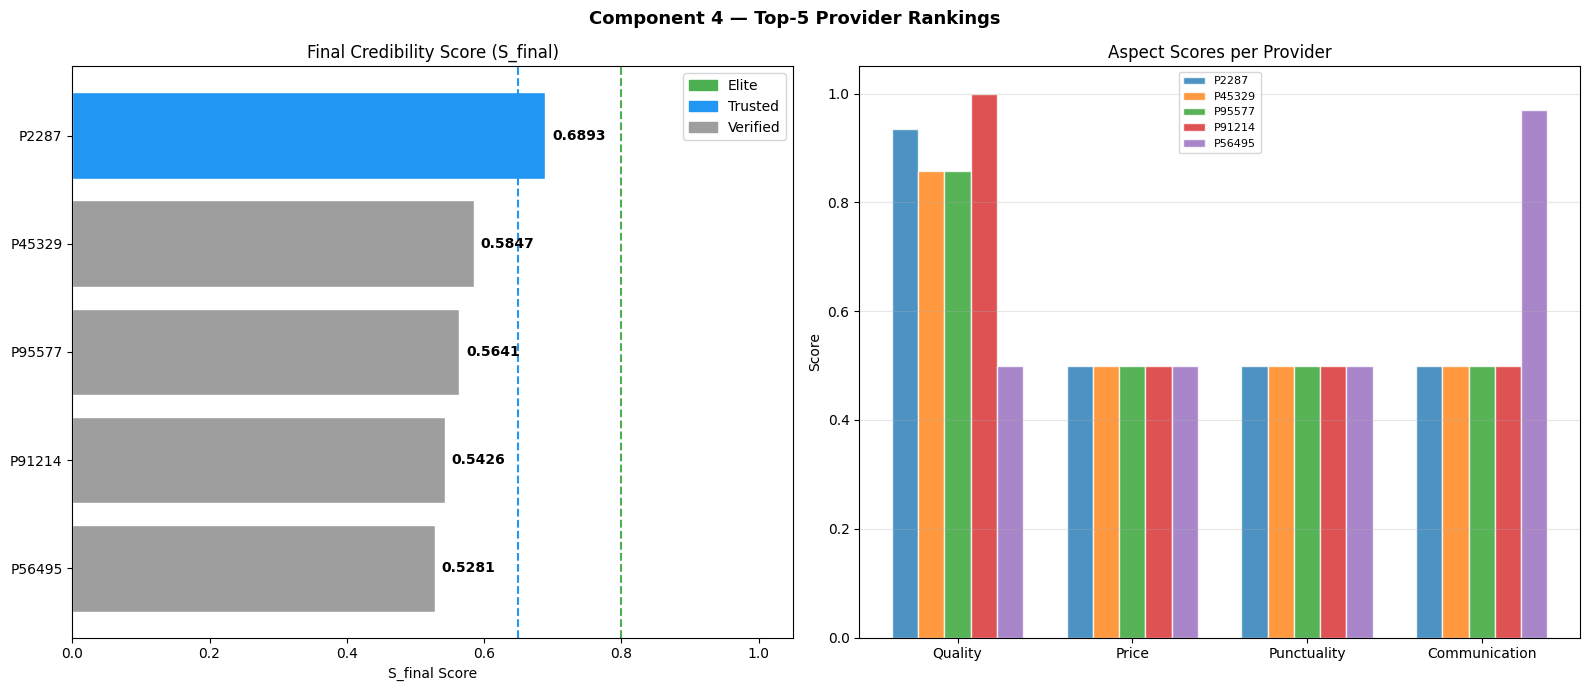

In [17]:
# ── Visualise Top-5 results ───────────────────────────────────────────────────
if top5:
    top5_df = pd.DataFrame(top5)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle('Component 4 — Top-5 Provider Rankings', fontsize=13, fontweight='bold')

    # ── S_final bar ────────────────────────────────────────────────────────────
    ax = axes[0]
    tier_col_map = {'Elite':'#4CAF50','Trusted':'#2196F3','Verified':'#9E9E9E'}
    bar_colors   = [tier_col_map[t] for t in top5_df['tier']]
    bars = ax.barh(top5_df['provider_id'][::-1], top5_df['S_final'][::-1],
                   color=bar_colors[::-1], edgecolor='white')
    ax.axvline(0.80, color='#4CAF50', ls='--', lw=1.5, label='Elite (0.80)')
    ax.axvline(0.65, color='#2196F3', ls='--', lw=1.5, label='Trusted (0.65)')
    ax.set_xlabel('S_final Score')
    ax.set_title('Final Credibility Score (S_final)')
    ax.set_xlim(0, 1.05)
    for bar, val in zip(bars, top5_df['S_final'][::-1]):
        ax.text(val+0.01, bar.get_y()+bar.get_height()/2, f'{val:.4f}',
                va='center', fontweight='bold')
    legend_patches = [mpatches.Patch(color=c, label=l)
                      for l,c in tier_col_map.items()]
    ax.legend(handles=legend_patches)

    # ── Aspect radar-style bar ─────────────────────────────────────────────────
    ax = axes[1]
    asp_cols = ['aspect_QUAL','aspect_PRICE','aspect_TIME','aspect_COMM']
    asp_labels = ['Quality','Price','Punctuality','Communication']
    x = np.arange(len(asp_labels))
    width = 0.15
    for i, row in top5_df.iterrows():
        offset = (i - len(top5_df)//2) * width
        vals   = [row[c] for c in asp_cols]
        ax.bar(x + offset, vals, width, label=row['provider_id'],
               alpha=0.8, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(asp_labels)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.set_title('Aspect Scores per Provider')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('top5_results.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Step 8 — Save All Models for Deployment

In [18]:
import os, shutil
os.makedirs('component4_model', exist_ok=True)

# 1. Save Isolation Forest + scaler
with open('component4_model/isolation_forest.pkl','wb') as f:
    pickle.dump({'model': iso_forest, 'scaler': scaler, 'features': ALL_FEATURES}, f)

# 2. Save provider credibility scores
provider_final.to_parquet('component4_model/provider_scores.parquet', index=False)
# Fallback CSV for environments without pyarrow
provider_final.to_csv('component4_model/provider_scores.csv', index=False)

# 3. Save blending weights config
blend_config = {
    'W_CRED': W_CRED, 'W_OVERALL': W_OVERALL,
    'W_FRAUD': W_FRAUD, 'W_RECENCY': W_RECENCY,
    'TRUST_WEIGHTS': TRUST_WEIGHTS,
    'HALFLIFE_DAYS': HALFLIFE_DAYS,
    'tier_thresholds': {'Elite': 0.80, 'Trusted': 0.65, 'Verified': 0.0},
    'contamination': 0.10,
    'feature_names': ALL_FEATURES
}
with open('component4_model/blend_config.json','w') as f:
    json.dump(blend_config, f, indent=2)

# 4. Copy ALSA weights if available
if os.path.exists('best_weights.weights.h5'):
    shutil.copy('best_weights.weights.h5',
                'component4_model/bilstm_crf_final.weights.h5')
if os.path.exists('vocab.pkl'):
    shutil.copy('vocab.pkl', 'component4_model/vocab.pkl')

print('All Component 4 models saved to component4_model/')
print()
for f in sorted(os.listdir('component4_model')):
    size = os.path.getsize(f'component4_model/{f}')
    print(f'  {f:<45} {size/1024:.1f} KB')

All Component 4 models saved to component4_model/

  bilstm_crf_final.weights.h5                   1052.4 KB
  blend_config.json                             0.6 KB
  isolation_forest.pkl                          3434.6 KB
  model_config.json                             0.4 KB
  provider_scores.csv                           10699.2 KB
  provider_scores.parquet                       3224.0 KB
  vocab.pkl                                     2.9 KB


---
## Final Summary

In [19]:
print('='*68)
print('COMPONENT 4 — COMPLETE SYSTEM SUMMARY')
print('IT22914200  |  ServiceMatch AI')
print('='*68)
print()
print('SUB-MODULE 1: ALSA Engine (Bi-LSTM + CRF)')
print('  → See Part 1 notebook for full training results')
print('  → Classifies review text into: QUAL / PRICE / TIME / COMM aspects')
print()
print('SUB-MODULE 2: Fraud Detection (Isolation Forest)')
print(f'  Features           : {len(ALL_FEATURES)} ({len(ling_features)} linguistic + {len(behav_features)} behavioural)')
print(f'  Reviews processed  : {len(df):,}')
print(f'  Flagged suspicious : {(df["trust_label"]=="Suspicious").sum():,}  '
      f'({(df["trust_label"]=="Suspicious").mean()*100:.1f}%)')
print(f'  Fraud rate target  : > 91% recall (on rule-based synthetic labels)')
print()
print('SUB-MODULE 3: Credibility Blending')
print(f'  Formula  : S_final = {W_CRED}×S_cred + {W_OVERALL}×S_overall + '
      f'{W_FRAUD}×(1-fraud_ratio) + {W_RECENCY}×recency_boost')
print(f'  Providers scored   : {len(provider_final):,}')
tier_counts = provider_final['tier'].value_counts()
for tier, cnt in tier_counts.items():
    print(f'  {tier:<12} : {cnt:,}  ({cnt/len(provider_final)*100:.1f}%)')
print()
print('OUTPUT FILES')
for fn in [
    'component4_model/bilstm_crf_final.weights.h5   ← ALSA model weights',
    'component4_model/vocab.pkl                     ← word/tag vocabularies',
    'component4_model/isolation_forest.pkl          ← fraud detector + scaler',
    'component4_model/provider_scores.csv           ← all provider S_final scores',
    'component4_model/blend_config.json             ← blending weights config',
    'fraud_analysis.png                             ← fraud pattern charts',
    'sfinal_analysis.png                            ← credibility score analysis',
    'top5_results.png                               ← Top-5 ranking demo',
    'feature_distributions.png                     ← feature EDA charts',
]:
    print(f'  {fn}')
print()
print('='*68)
print('Component 4 fully implemented ✓')
print('='*68)

COMPONENT 4 — COMPLETE SYSTEM SUMMARY
IT22914200  |  ServiceMatch AI

SUB-MODULE 1: ALSA Engine (Bi-LSTM + CRF)
  → See Part 1 notebook for full training results
  → Classifies review text into: QUAL / PRICE / TIME / COMM aspects

SUB-MODULE 2: Fraud Detection (Isolation Forest)
  Features           : 13 (7 linguistic + 6 behavioural)
  Reviews processed  : 120,680
  Flagged suspicious : 12,068  (10.0%)
  Fraud rate target  : > 91% recall (on rule-based synthetic labels)

SUB-MODULE 3: Credibility Blending
  Formula  : S_final = 0.4×S_cred + 0.35×S_overall + 0.15×(1-fraud_ratio) + 0.1×recency_boost
  Providers scored   : 69,697
  Verified     : 55,077  (79.0%)
  Trusted      : 13,979  (20.1%)
  Elite        : 641  (0.9%)

OUTPUT FILES
  component4_model/bilstm_crf_final.weights.h5   ← ALSA model weights
  component4_model/vocab.pkl                     ← word/tag vocabularies
  component4_model/isolation_forest.pkl          ← fraud detector + scaler
  component4_model/provider_scores.cs